In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

DATA_DIR = "data"
TRAIN_IMAGES = os.path.join(DATA_DIR, "train_images")

df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

In [3]:
# Q1. Examining Structure
print(f"Data shape: {df.shape}")
print(f"Data's columns name: {df.columns}")

# Q2. Unique Images inside train_images and train.csv
print(f"Unique Images: {df["ImageId"].nunique()}")
print(f"Total Images: {len(os.listdir(TRAIN_IMAGES))}")

# Q3. Unique Defects class IDs + if any are missing
print(df["ClassId"].unique())
print(f"Null EncodedPixels: {df["EncodedPixels"].isnull().sum()}")

Data shape: (7095, 3)
Data's columns name: Index(['ImageId', 'ClassId', 'EncodedPixels'], dtype='str')
Unique Images: 6666
Total Images: 12568
[1 3 4 2]
Null EncodedPixels: 0


ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64


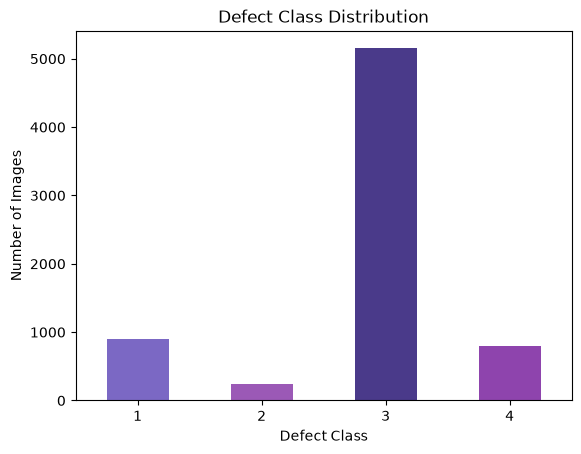

In [4]:
# Q4. Counting Defective images + Bar Chart
defective = df[df["EncodedPixels"].notna()]
class_counts = defective["ClassId"].value_counts().sort_index()
print(class_counts)

# Bar Chart
class_counts.plot(kind="bar", color=["#7B68C4", "#9B59B6", "#4A3A8A", "#8E44AD"])
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Defect Class Distribution")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Q5. Images with no defects
all_images = set(os.listdir(TRAIN_IMAGES))
defective_images = set(defective["ImageId"].unique())
no_defect_images = all_images - defective_images
print(f"Images with NO Defect: {len(no_defect_images)}")
print(f"Defect Images: {len(defective_images)}")


Images with NO Defect: 5902
Defect Images: 6666


ClassId
1     897
2     247
3    5150
4     801
5    5902
Name: count, dtype: object


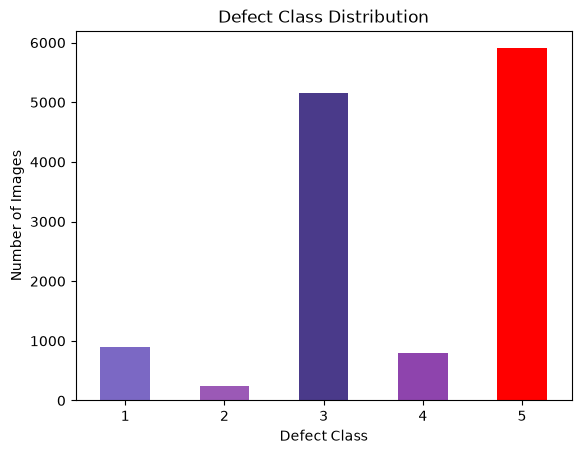

In [ ]:
# Q6. 5 classes count table
class_counts["5"] = len(no_defect_images)
print(class_counts)

class_counts.plot(kind="bar", color=["#7B68C4", "#9B59B6", "#4A3A8A", "#8E44AD", "red"])
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Defect Class Distribution")
plt.xticks(rotation=0)
plt.show()

In [16]:
# Q7. Single image with more than one defect??
defects_per_image = defective.groupby("ImageId")["ClassId"].unique()
print(defects_per_image.value_counts())

ClassId
[3]       4759
[1]        769
[4]        516
[2]        195
[3, 4]       1
          ... 
[3, 4]       1
[3, 4]       1
[1, 3]       1
[3, 4]       1
[1, 2]       1
Name: count, Length: 431, dtype: int64


In [18]:
# Q8. Class Combinations
multi = defective.groupby("ImageId")["ClassId"].apply(
    lambda x: tuple(sorted(x.unique())) 
)

multi_only = multi[multi.apply(len) > 1]
print(multi_only.value_counts())

ClassId
(3, 4)       284
(1, 3)        91
(1, 2)        35
(2, 3)        14
(1, 2, 3)      2
(2, 4)         1
Name: count, dtype: int64


In [ ]:
# Q9. ANSWER:
# If an image has more than one class but my model is only restricted to pick one,
# I would make the model to choose the one with the bigger probability. 
# Another option would be to simple give an additional label as a fallback,
# that the model returns if the image has more than one or if the probabilities are exactly 50/50.
# Something like "Various Defects Detected".

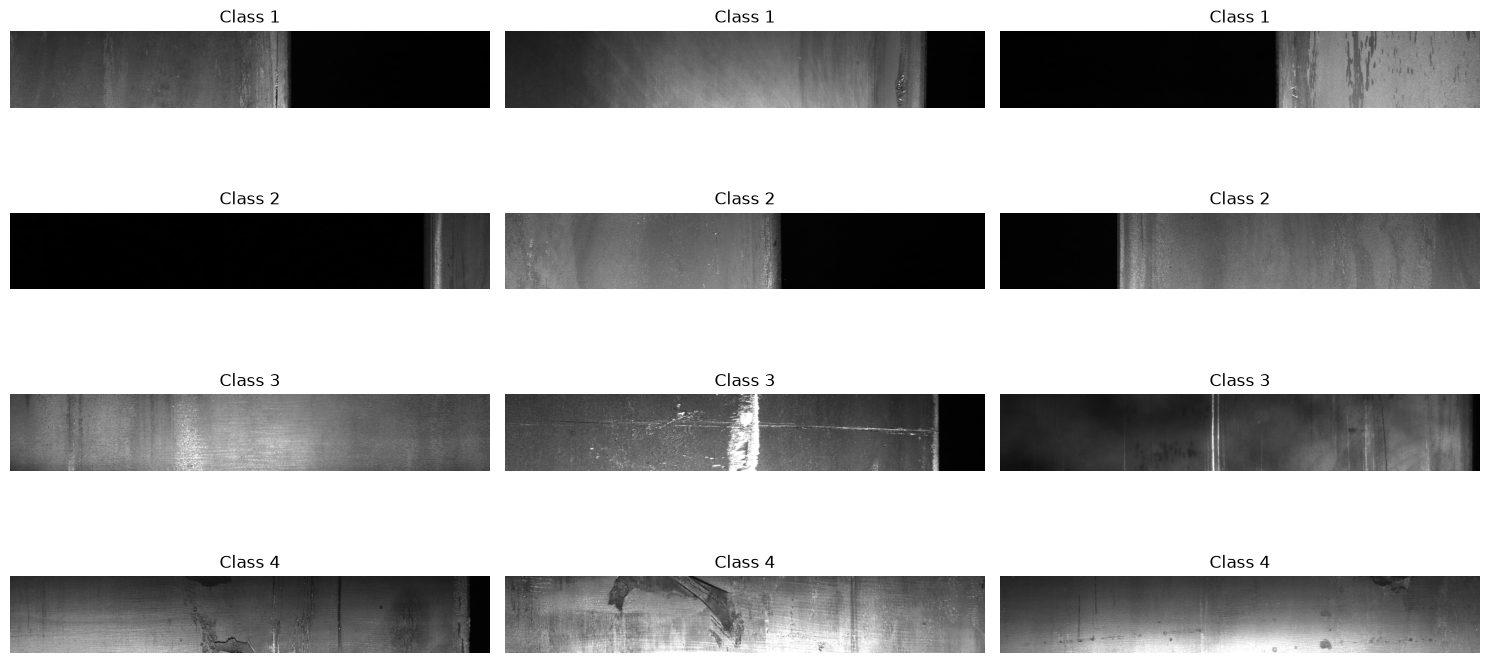

In [ ]:
# Q10. Displaying Image Samples
fig, axes = plt.subplots(4, 3, figsize=(15, 8))

for row, class_id in enumerate([1, 2, 3, 4]):
    class_images = defective[defective["ClassId"] == class_id]["ImageId"].unique()
    samples = np.random.choice(class_images, size=3, replace=False)

    for col, img_name in enumerate(samples):
        img = Image.open(os.path.join(TRAIN_IMAGES, img_name))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"Class {class_id}")
        axes[row, col].axis("off")
    
plt.tight_layout()
plt.show()

# I don't think I would be able to tell these apart,
# class 4 seems to be the one with the more severe defect
# but the rest are very similar, or at least not obvious at first sight.

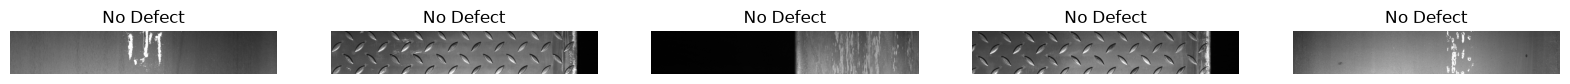

In [ ]:
# Q11. Displaying no defect images
no_defect_samples = np.random.choice(list(no_defect_images), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for i, img_name in enumerate(no_defect_samples):
    img = Image.open(os.path.join(TRAIN_IMAGES, img_name))
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title("No Defect")
    axes[i].axis("off")

# No-defected images don't look exactly that clean, exept for the ones with texture,
# the plains ones look very similar to any defect ones.

In [34]:
# Q12. Image Dimensions
samples_imgs = np.random.choice(class_images, size=5, replace=False)
sample_img = Image.open(os.path.join(TRAIN_IMAGES, os.listdir(TRAIN_IMAGES)[0]))

for i, img_name in enumerate(samples_imgs):
    image = Image.open(os.path.join(TRAIN_IMAGES, img_name))
    print(f"Size: {image.size}") # (width , height)

Size: (1600, 256)
Size: (1600, 256)
Size: (1600, 256)
Size: (1600, 256)
Size: (1600, 256)


In [ ]:
# Q13. ANSWER:
# Based on everything I have found, I believe the most challanging part facing this data is the
# inequality in amount of samples for each class, as we saw in the plots, class 3 and class 5(no defect)
# have +5000 samples while the rest of the classes have barely 1000. Another challenge connected the one before
# would be to find a way to how to augment/add more samples to these classes. Plus possible having to resize
# images from (1600, 256) to (224, 224). The last challange would be to actually label the classes, since
# I defenetivly can't tell them apart.

# Q14. ANSWER: 
# EncodedPixels, besides from confirming the image has a defect, it also has the pixel locations, meaning
# we could technically draw/plot all these pixels on top of their correspondand image and see the masks.
# Meaning, so far, we have been ignoring the "masks" of every image.
# This might matter if we decide to also add segmentation to our model.